# Section 4.2

## Example 4.2.

In [21]:
using Polynomials
p = Polynomial([3.5, -4, 1])
r = roots(p)
rmin, rmax = extrema(r)
@show rmin, rmax;

(rmin, rmax) = (1.2928932188134525, 2.7071067811865475)


$$ g(x) = x - p(x) $$

In [22]:
g(x) = x - p(x)

g (generic function with 1 method)

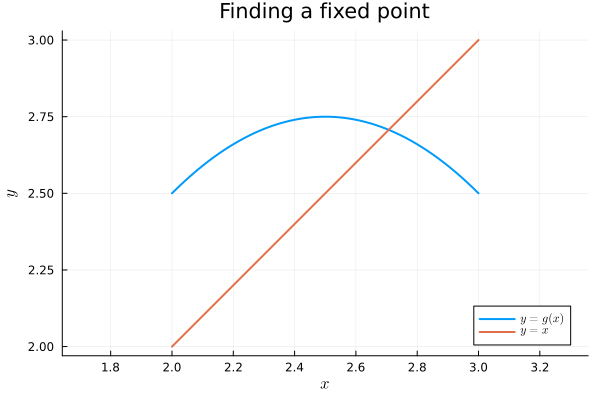

In [23]:
using Plots, LaTeXStrings
plt = plot([g x->x], 2, 3;
    l=2, label=[L"y=g(x)" L"y=x"], xlabel=L"x",  ylabel=L"y", aspect_ratio=1,
    title="Finding a fixed point",  legend=:bottomright)

In [24]:
x = 2.1;
y = g(x)

2.59

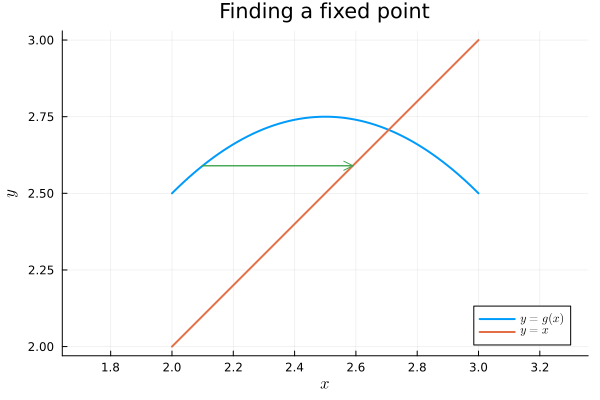

In [25]:
plot!([x, y], [y, y], arrow=true, label="", color=3)

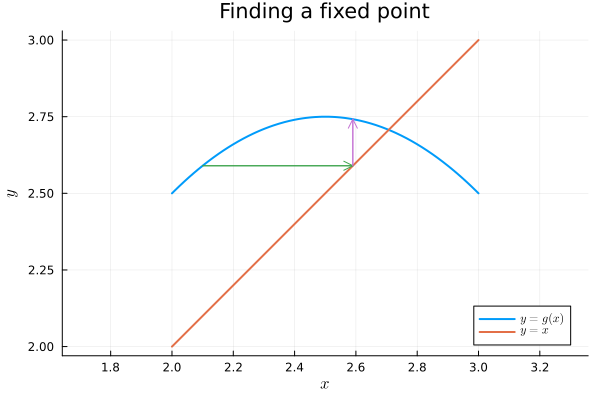

In [26]:
x = y;  y = g(x)
plot!([x, x], [x, y], arrow=true, label="", color=4)

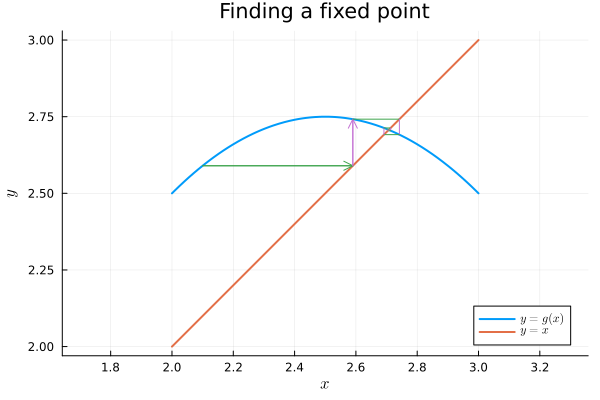

In [27]:
for k = 1:5
    plot!([x, y], [y, y], color=3, label="");  
    x = y                               # y becomes the new x
    y = g(x)                            # g(x) becomes the new y
    plot!([x, x], [x, y], color=4, label="")  
end
plt

In [28]:
abs(y - rmax) / rmax

0.0001653094344995643

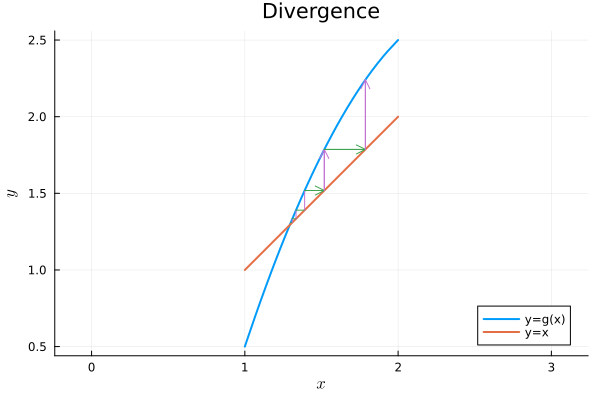

In [29]:
plt = plot([g x->x], 1, 2, l=2, label=["y=g(x)" "y=x"], aspect_ratio=1, 
    xlabel=L"x", ylabel=L"y", title="Divergence", legend=:bottomright)

x = 1.3; y = g(x);
arrow = false
for k = 1:5
    plot!([x, y], [y, y], arrow=arrow, label="", color=3)  
    x = y       # y --> new x
    y = g(x)    # g(x) --> new y
    plot!([x, x], [x, y], arrow=arrow, label="", color=4)
    if k > 2; arrow = true; end
end
plt

## Example 4.23

In [10]:
using Polynomials
p = Polynomial([3.5, -4, 1])
r = roots(p)
rmin, rmax = extrema(r)

(1.2928932188134525, 2.7071067811865475)

In [11]:
g(x) = x - p(x)
x = [2.1]
for k = 1:12
    push!(x, g(x[k]))
end
x

13-element Vector{Float64}:
 2.1
 2.59
 2.7419000000000002
 2.69148439
 2.713333728386328
 2.7044887203327885
 2.7081843632566587
 2.7066592708954196
 2.7072919457529734
 2.7070300492259465
 2.707138558717502
 2.707093617492436
 2.7071122335938966

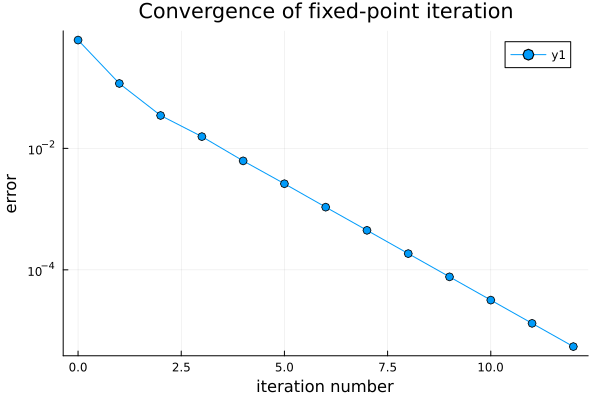

In [12]:
using Plots
err = @. abs(x - rmax)
plot(0:12, err;
    m=:o, xaxis=("iteration number"),  yaxis=("error", :log10),
    title="Convergence of fixed-point iteration")

In [13]:
y = log.(err[5:12])
p = Polynomials.fit(5:12, y, 1)

Polynomial(-0.6680573888302033 - 0.8807181589734457*x)

In [14]:
σ = exp(p.coeffs[2])

0.4144851385485472

In [15]:
[err[i+1] / err[i] for i in 8:11]

4-element Vector{Float64}:
 0.4137660520817109
 0.4143987269383
 0.4141368304124451
 0.4142453399049934